# The Hamiltonian Monte Carlo Algorithm

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import torch
import torch.nn as nn
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

## Leapfrog vs Euler discretization

First let us see why the Leapfrog discretization is better than the Euler discretization. We shall take the case of the standard Gaussian density $\pi(x) \propto \exp(-\|x\|^2/2)$, where the continuous time Hamiltonian ODE has the exact solution: $x(t) = x \cos t + z \sin t$. In this case, we can compare the closeness of $x(\sigma)$ with approximations of $x(\sigma)$ calculated using Euler and Leapfrog dynamics. We shall $N = 200$ and the stepsize $\epsilon = \sigma/N$. 

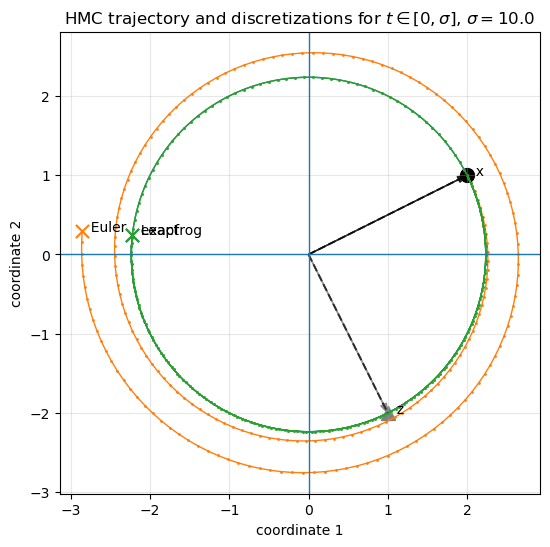

In [2]:
# parameters
sigma = 10.0
x = np.array([2.0, 1.0])

# one fixed draw z ~ N(0, I_2)
# np.random.seed(0)
#z = np.random.randn(2)
z = np.array([1.0, -2.0])

# exact HMC trajectory for Gaussian target
t = np.linspace(0, sigma, 300)
T3 = np.cos(t)[:, None] * x[None, :] + np.sin(t)[:, None] * z[None, :]

# discretization settings
N = 200
h = sigma / N

# Euler discretization
x_eu = x.copy()
v_eu = z.copy()
T_euler = [x_eu.copy()]

for _ in range(N):
    x_new = x_eu + h * v_eu
    v_new = v_eu - h * x_eu
    x_eu, v_eu = x_new, v_new
    T_euler.append(x_eu.copy())

T_euler = np.array(T_euler)

# Leapfrog discretization
x_lf = x.copy()
v_lf = z.copy()
T_leapfrog = [x_lf.copy()]

for _ in range(N):
    v_half = v_lf - 0.5 * h * x_lf
    x_new = x_lf + h * v_half
    v_new = v_half - 0.5 * h * x_new
    x_lf, v_lf = x_new, v_new
    T_leapfrog.append(x_lf.copy())

T_leapfrog = np.array(T_leapfrog)

# endpoints
T3_end = T3[-1]
Te_end = T_euler[-1]
Tl_end = T_leapfrog[-1]

plt.figure(figsize=(12, 6))

# trajectories
plt.plot(T3[:, 0], T3[:, 1], linewidth=1, label=r"Exact HMC: $x\cos t+z\sin t$")
plt.plot(T_euler[:, 0], T_euler[:, 1], 'o-', linewidth=1, markersize=1, label="Euler")
plt.plot(T_leapfrog[:, 0], T_leapfrog[:, 1], 's-', linewidth=1, markersize=1, label="Leapfrog")

# connect origin to x and z
plt.plot([0, x[0]], [0, x[1]], 'k--', alpha=0.7)
plt.plot([0, z[0]], [0, z[1]], 'k--', alpha=0.7)

# arrows from origin to x and z
plt.arrow(0, 0, x[0], x[1],
          head_width=0.08, length_includes_head=True, alpha=0.8, color='black')
plt.arrow(0, 0, z[0], z[1],
          head_width=0.08, length_includes_head=True, alpha=0.8, color='gray')

# mark x and z
plt.scatter(x[0], x[1], s=100, marker='o', color='black', label="x")
plt.scatter(z[0], z[1], s=100, marker='^', color='gray', label="z")

# mark endpoints
plt.scatter(T3_end[0], T3_end[1], s=90, marker='x')
plt.scatter(Te_end[0], Te_end[1], s=90, marker='x')
plt.scatter(Tl_end[0], Tl_end[1], s=90, marker='x')

plt.text(x[0], x[1], "  x")
plt.text(z[0], z[1], "  z")
plt.text(T3_end[0], T3_end[1], r"  exact")
plt.text(Te_end[0], Te_end[1], r"  Euler")
plt.text(Tl_end[0], Tl_end[1], r"  Leapfrog")

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True, alpha=0.3)
#plt.legend()
plt.title(fr"HMC trajectory and discretizations for $t\in[0,\sigma]$, $\sigma={sigma}$")
plt.xlabel("coordinate 1")
plt.ylabel("coordinate 2")
plt.show()

It is clear that the leapfrog approximation is very accurate. Euler discretization, on the other hand, starts to deviate from the correct path after a few initial steps. 

## Fitting a Bayesian Neural Network Regression model using HMC

We will fit a two-hidden layer neural network model using HMC. Given a response variable $y$ and covariate vector $x = (x_1, \dots, x_d)$, the two-hidden layer neural network model is given by: 
\begin{align*}
    y = f_{\theta}(x) + \epsilon
\end{align*}
where $f_{\theta}(x)$ is: 
\begin{align*}
   f_{\theta}(x) = W_3^T \sigma \left( W_2^T \sigma(W_1^T x + b_1) + b_2 \right) + b_3
\end{align*}
The vector $\theta$ of parameters contains all the entries of $W_1, W_2, W_3, b_1, b_2, b_3$. This is a two-hidden layer network because the function $f_{\theta}(x)$ can be thought of as being constructed as: 
\begin{align*}
   x \overset{\text{layer 1}}{\rightarrow} h^{(1)} := \sigma(W_1^T x + b_1) \overset{\text{layer 2}}{\rightarrow} h^{(2)} := \sigma(W_2^T h^{(1)} + b_2) \overset{\text{output}}{\rightarrow} f_{\theta}(x) = W_3^T h^{(2)} + b_3. 
\end{align*}
$h^{(1)}$ and $h^{(2)}$ constitute the variables in the two hidden layers. 

We shall apply this regression to the diabetes dataset (this is a standard benchmark dataset for regression from the library scikitlearn). 

In [3]:
import pandas as pd
from sklearn.datasets import load_diabetes

data = load_diabetes()

X = data.data
y = data.target

df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y

print(df.head())

        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  


Here target will be our response variable $y$. This is a quantitative measure of diabetes progression measured one year after baseline. The other variables are all covariates. $s_1, \dots, s_6$ are numerical blood serum measurements: total cholestrol (s1), LDL (s2), HDL (s3), colesterol/HDL ratio (s4), log of triglycerides (s5) and blood sugar level (s6). 

Below we split the data into training and test datasets. 

In [4]:
seed = 123
X_train, X_test, y_train_raw, y_test_raw = train_test_split(X, y, test_size=0.25, random_state=seed)

Below we standardize the training data (and then apply the same standardization to the test data). 

In [5]:
x_scaler = StandardScaler()
X_train = x_scaler.fit_transform(X_train)
X_test = x_scaler.transform(X_test)

y_mean = y_train_raw.mean()
y_std = y_train_raw.std()

y_train = (y_train_raw - y_mean) / y_std
y_test = (y_test_raw - y_mean) / y_std

The standard approach for these kinds of regressions uses least squares estimation (along with a standard gradient based optimization method to minimize the least squares objective): 
\begin{align*}
   \hat{\theta} \in \text{argmin}  \frac{1}{n}\sum_{i=1}^n \left(y_i - f_{\theta}(x_i) \right)^2. 
\end{align*}
It is also common to include a ridge regularization penalty to the least squares objective: 
\begin{align*}
   \hat{\theta} \in \text{argmin}  \left[ \frac{1}{n}\sum_{i=1}^n \left(y_i - f_{\theta}(x_i) \right)^2 + \lambda \|\theta\|^2 \right]. 
\end{align*}
This ridge penalty is referred to as weight-decay in the machine learning literature. 

PyTorch is a standard library that contains functions for minimizing such objective functions. In order to apply PyTorch, we need to convert the data into tensors; this is done below. 

In [6]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

We shall fit a neural network with two hidden layers. The number of variables in each hidden layer is taken to be 20 (this is the length of the variables $h^{(1)}$ and $h^{(2)}$). 

In [7]:
print(X_train.shape[1])
layer_sizes = [X_train.shape[1], 20, 20, 1]

10


The total number of parameters in this neural network (i.e., the length of $\theta$) is calculated below. 

In [8]:
def num_params(layer_sizes):
    total = 0
    for din, dout in zip(layer_sizes[:-1], layer_sizes[1:]):
        total += din * dout + dout
    return total

D = num_params(layer_sizes)
print("Number of BNN parameters:", D)

Number of BNN parameters: 661


The number of parameters is 661. 

The following function converts a single long parameter vector $\theta$ to the weights and biases $W_i$ and $b_i$. 

In [9]:
def unpack_theta(theta, layer_sizes):
    """
    Converts a flat parameter vector theta into weight matrices and bias vectors.
    """
    params = []
    idx = 0
    for din, dout in zip(layer_sizes[:-1], layer_sizes[1:]):
        W = theta[idx: idx + din * dout].reshape(din, dout)
        idx += din * dout
        b = theta[idx: idx + dout].reshape(1, dout)
        idx += dout
        params.append((W, b))
    return params

The following gives the equation for the neural network model that we use. For the activation function $\sigma$, we shall use the tanh function. 

In [10]:
def bnn_forward(theta, X, layer_sizes):
    """
    Forward pass for fully connected tanh neural network.
    """
    params = unpack_theta(theta, layer_sizes)
    h = X
    for ell, (W, b) in enumerate(params):
        h = h @ W + b
        if ell < len(params) - 1:
            h = torch.tanh(h)
    return h

Below is the code for fitting the model using the standard approach. We minimize least squares using Stochastic Gradient Descent with random initialization along with a possible weight-decay. 

In [11]:
class SGDNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 1),
        )

    def forward(self, x):
        return self.net(x)


sgd_model = SGDNet(X_train.shape[1]).float()

criterion = nn.MSELoss()

weight_decay = 1e-1 #1e-1 seems to work well
optimizer = torch.optim.SGD(
    sgd_model.parameters(),
    lr=0.01,
    momentum=0.9,
    weight_decay=weight_decay,
)

n_epochs = 5000

for epoch in range(n_epochs):
    optimizer.zero_grad()

    pred = sgd_model(X_train_t)
    loss = criterion(pred, y_train_t)

    loss.backward()
    optimizer.step()

    if (epoch + 1) % 500 == 0:
        with torch.no_grad():
            test_pred = sgd_model(X_test_t)
            test_rmse = torch.sqrt(torch.mean((test_pred - y_test_t) ** 2)).item()
        print(
            f"SGD epoch {epoch+1:4d}, "
            f"train loss = {loss.item():.4f}, "
            f"test RMSE = {test_rmse:.4f}"
        )


with torch.no_grad():
    sgd_pred = sgd_model(X_test_t)

sgd_rmse_standardized = torch.sqrt(torch.mean((sgd_pred - y_test_t) ** 2)).item()
sgd_rmse_original = sgd_rmse_standardized * y_std

print("\nFrequentist NN via SGD")
print("Test RMSE, standardized scale:", sgd_rmse_standardized)
print("Test RMSE, original scale:", sgd_rmse_original)

SGD epoch  500, train loss = 0.4871, test RMSE = 0.7094
SGD epoch 1000, train loss = 0.4875, test RMSE = 0.7094
SGD epoch 1500, train loss = 0.4876, test RMSE = 0.7094
SGD epoch 2000, train loss = 0.4877, test RMSE = 0.7094
SGD epoch 2500, train loss = 0.4878, test RMSE = 0.7094
SGD epoch 3000, train loss = 0.4878, test RMSE = 0.7094
SGD epoch 3500, train loss = 0.4879, test RMSE = 0.7094
SGD epoch 4000, train loss = 0.4879, test RMSE = 0.7094
SGD epoch 4500, train loss = 0.4879, test RMSE = 0.7094
SGD epoch 5000, train loss = 0.4879, test RMSE = 0.7094

Frequentist NN via SGD
Test RMSE, standardized scale: 0.7094035744667053
Test RMSE, original scale: 54.58078543069036


After some trial and error, it can be discovered that a weight decay of 0.1 works well. Without weight decay, SGD run for 5000 epochs does not seem to work well (the test error seems to increase with iterations). The overall test error for this method is 54.58. 

### HMC for fitting this Bayesian Neural Network

We shall now fit this model using a Bayesian approach and Hamiltonian Monte Carlo. For the prior, we use $N(0, \tau^2)$ for all the weights and biases. The posterior therefore (note that we are using, as usual, the $N(0, \sigma^2)$ prior on the errors): 
\begin{align*}
   \pi(\theta) \propto \exp \left[-\frac{1}{2 \sigma^2} \sum_{i=1}^n \left(y_i - f_{\theta}(x_i) \right)^2 - \frac{1}{2 \tau^2} \|\theta\|^2 \right]. 
\end{align*}
We are assuming that $\sigma$ and $\tau$ are known so terms involving these parameters can be ignored as constants. 

We now use HMC for inferring all the weights and biases. In this code, we shall fix values of $\sigma$ and $\tau$ (instead of using priors on them). 

The Hamiltonian is given by $H(\theta, v) = -\log \pi(\theta) + 0.5 \|v\|^2$. The function $U(\theta) = -\log \pi(\theta)$ is called the potential energy. It is computed using the following code (note that $\pi(\theta)$ is our posterior). 

In [12]:
def potential_energy(theta):
    """
    U(theta) = negative log posterior up to an additive constant.
    Model:
        y_i | theta ~ N(f_theta(x_i), sigma^2)
    Prior:
        theta_j ~ N(0, tau^2), independently.
    """
    pred = bnn_forward(theta, X_train_t, layer_sizes)
    resid = y_train_t - pred
    neg_log_lik = 0.5 * torch.sum(resid ** 2) / sigma**2
    neg_log_prior = 0.5 * torch.sum(theta ** 2) / tau**2
    return neg_log_lik + neg_log_prior

To implement HMC, we would need to calculate gradients of $\log \pi(\theta)$. For this, we shall use PyTorch. 

In [13]:
def U_and_grad(theta):
    """
    Returns U(theta) and grad U(theta).
    """
    theta = theta.detach().clone().requires_grad_(True)
    U = potential_energy(theta)
    grad = torch.autograd.grad(U, theta)[0]
    return U.detach(), grad.detach()

The following is the main function for HMC. $\epsilon$ denotes the step size in leapfrog discretization, and $L$ denotes the number of leapfrog steps. 

In [14]:
def hmc_step(theta, epsilon, L):
    """
    One Hamiltonian Monte Carlo transition.

    Hamiltonian:
        H(theta, v) = U(theta) + 0.5 ||v||^2

    Momentum:
        v ~ N(0, I)
    """
    theta_current = theta.detach().clone()
    v_current = torch.randn_like(theta_current)

    current_U, current_grad = U_and_grad(theta_current)
    current_K = 0.5 * torch.sum(v_current ** 2)

    theta_new = theta_current.clone()
    v_new = v_current.clone()

    # First half momentum update
    v_new = v_new - 0.5 * epsilon * current_grad

    # Leapfrog integration
    for j in range(L):
        theta_new = theta_new + epsilon * v_new
        U_new, grad_new = U_and_grad(theta_new)
        if j != L - 1:
            v_new = v_new - epsilon * grad_new

    # Final half momentum update
    v_new = v_new - 0.5 * epsilon * grad_new

    # Momentum flip for reversibility
    v_new = -v_new

    proposed_U = U_new
    proposed_K = 0.5 * torch.sum(v_new ** 2)

    log_accept_ratio = (
        current_U + current_K - proposed_U - proposed_K
    )

    if torch.log(torch.rand(())) < log_accept_ratio:
        return theta_new.detach(), True, proposed_U.item()
    else:
        return theta_current.detach(), False, current_U.item()

Below we implement HMC. It is important to choose good values of $\sigma$ and $\tau$. For this, we shall use the fitted SGD solution (with weight-decay equal to 0.1) as a baseline. If this SGD solution is denoted by $\hat{\theta}$, a reasonable value of $\sigma$ is given by: 
\begin{align*}
   \sqrt{\frac{1}{n} \sum_{i=1}^n \left(y_i - f_{\hat{\theta}}(x_i) \right)^2}.
\end{align*}
Further, the least squares with weight-decay solution minimizes: 
\begin{align*}
   \frac{1}{n} \sum_{i=1}^n \left(y_i - f_{\theta}(x_i) \right)^2 + \lambda \|\theta\|^2
\end{align*}
which looks very similar to the negative of the term inside the exponent of the posterior: 
\begin{align*}
   \frac{1}{2\sigma^2} \sum_{i=1}^n \left(y_i - f_{\theta}(x_i) \right)^2 + \frac{1}{2 \tau^2} \|\theta\|^2. 
\end{align*}
Comparing these two expressions, it is reasonable to tune $\tau$ via $\sigma^2/\tau^2 = \lambda$ which gives $\tau = \sqrt{\sigma^2/\lambda}$. Note that we have taken $\lambda = 0.1$ as the weight decay parameter. Using these ideas, we obtain $\sigma$ and $\tau$ as follows.



In [15]:
with torch.no_grad():
    train_pred = sgd_model(X_train_t)
    resid = y_train_t - train_pred
    sigma_hat = torch.sqrt(torch.mean(resid ** 2)).item()

print("\nEstimated sigma (standardized scale):", sigma_hat)

# -----------------------------
# Compute implied tau
# -----------------------------
n = X_train_t.shape[0]
lam = weight_decay

tau_hat = sigma_hat / np.sqrt(n * lam)

print("Implied tau from SGD:", tau_hat)


Estimated sigma (standardized scale): 0.6985073685646057
Implied tau from SGD: 0.1214107089175022


We got $\sigma \approx 0.7$ and $\tau \approx 0.12$. We shall use these values in the HMC code below. We choose random values as initial values for $\theta$. We run leapfrog steps with stepsize 0.03 and number of steps 100, and obtain a total of 1000 samples.  

In [29]:
sigma = 0.7
tau = 0.12

theta = 0.1 * torch.randn(D)

# HMC tuning parameters
epsilon = 0.03
L = 100
n_samples = 1000

samples = []
accepts = []

for it in range(n_samples):
    theta, accepted, U_val = hmc_step(theta, epsilon=epsilon, L=L)

    samples.append(theta.clone())
    accepts.append(accepted)

    if (it + 1) % 100 == 0:
        recent_acc = np.mean(accepts[-100:])
        print(
            f"HMC iter {it+1:4d} / {n_samples}, "
            f"recent accept = {recent_acc:.3f}, "
            f"U = {U_val:.2f}"
        )

samples = torch.stack(samples)
accept_rate = np.mean(accepts)

print("\nFinal HMC acceptance rate:", accept_rate)

HMC iter  100 / 1000, recent accept = 0.780, U = 525.46
HMC iter  200 / 1000, recent accept = 0.750, U = 534.37
HMC iter  300 / 1000, recent accept = 0.720, U = 529.53
HMC iter  400 / 1000, recent accept = 0.850, U = 545.59
HMC iter  500 / 1000, recent accept = 0.700, U = 529.81
HMC iter  600 / 1000, recent accept = 0.750, U = 549.33
HMC iter  700 / 1000, recent accept = 0.770, U = 535.75
HMC iter  800 / 1000, recent accept = 0.810, U = 564.83
HMC iter  900 / 1000, recent accept = 0.790, U = 562.32
HMC iter 1000 / 1000, recent accept = 0.800, U = 559.36

Final HMC acceptance rate: 0.772


The samples of $\theta$ can be used to predict the response from covariates in the test dataset as follows.

In [30]:
with torch.no_grad():
    preds = []
    for s in samples:
        preds.append(bnn_forward(s, X_test_t, layer_sizes))
    preds = torch.stack(preds)          # shape: n_samples x n_test x 1
    pred_mean = preds.mean(dim=0)       # posterior predictive mean
    pred_sd = preds.std(dim=0)          

hmc_rmse_standardized = torch.sqrt(torch.mean((pred_mean - y_test_t) ** 2)).item()
hmc_rmse_original = hmc_rmse_standardized * y_std

print("\nBayesian NN via HMC")
print("Test RMSE, standardized scale:", hmc_rmse_standardized)
print("Test RMSE, original scale:", hmc_rmse_original)


Bayesian NN via HMC
Test RMSE, standardized scale: 0.718383252620697
Test RMSE, original scale: 55.27167268330693


The accuracy is comparable to that of the SGD based solution with weight-decay. 